# 01 — Análise Exploratória (EDA)
**BOVA11 ML Pipeline**

Objetivo: entender a estrutura dos dados históricos do BOVA11, identificar padrões sazonais, distribuição de retornos e comportamento da volatilidade.

---

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 1. Download dos dados

In [10]:
ticker = 'BOVA11.SA'
start  = '2015-01-01'
end    = '2024-12-31'

raw = yf.download(ticker, start=start, end=end, auto_adjust=True)
raw.columns = [c[0].lower() for c in raw.columns]
raw = raw[['open', 'high', 'low', 'close', 'volume']].dropna()

print(f'Shape: {raw.shape}')
print(f'Período: {raw.index[0].date()} → {raw.index[-1].date()}')
raw.tail(3)

[*********************100%***********************]  1 of 1 completed

Shape: (2460, 5)
Período: 2015-01-02 → 2024-12-30


,open,high,low,close,volume
Date,,,,,
2024-12-26,117.900002,118.570000,117.389999,117.959999,3231104
2024-12-27,118.300003,118.470001,117.019997,117.260002,6917466
2024-12-30,117.430000,118.000000,117.080002,117.269997,6590812


## 2. Série de preços e volume

In [11]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    row_heights=[0.7, 0.3],
                    subplot_titles=['Preço de fechamento (BOVA11)', 'Volume'])

fig.add_trace(go.Scatter(x=raw.index, y=raw['close'],
                         line=dict(color='#2563eb', width=1.5),
                         name='Fechamento'), row=1, col=1)

fig.add_trace(go.Bar(x=raw.index, y=raw['volume'],
                     marker_color='#94a3b8', name='Volume'), row=2, col=1)

fig.update_layout(height=500, showlegend=False,
                  title_text='BOVA11 — Histórico de preços',
                  template='plotly_white')
fig.show()

## 3. Retornos diários

In [12]:
raw['retorno'] = raw['close'].pct_change()
raw['retorno_log'] = np.log(raw['close'] / raw['close'].shift(1))
raw = raw.dropna()

ret = raw['retorno']

print('=== Estatísticas dos retornos diários ===')
print(f'Média diária:      {ret.mean():.4%}')
print(f'Desvio padrão:     {ret.std():.4%}')
print(f'Assimetria:        {ret.skew():.4f}')
print(f'Curtose:           {ret.kurt():.4f}')
print(f'Mínimo:            {ret.min():.4%}')
print(f'Máximo:            {ret.max():.4%}')
print(f'% dias positivos:  {(ret > 0).mean():.2%}')

=== Estatísticas dos retornos diários ===
Média diária:      0.0489%
Desvio padrão:     1.5371%
Assimetria:        -0.6065
Curtose:           12.3487
Mínimo:            -14.5747%
Máximo:            13.3951%
% dias positivos:  52.42%


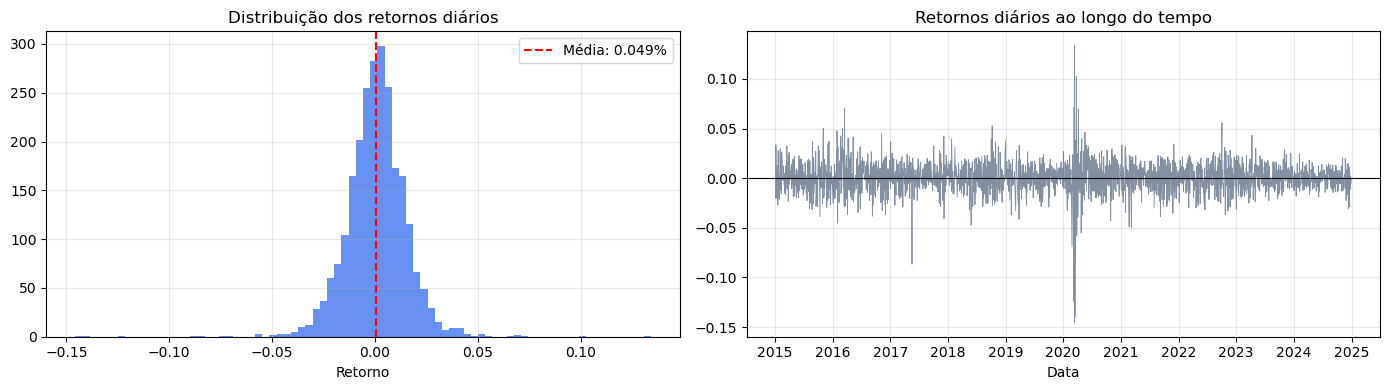

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
axes[0].hist(ret, bins=80, color='#2563eb', alpha=0.7, edgecolor='none')
axes[0].axvline(ret.mean(), color='red', linestyle='--', label=f'Média: {ret.mean():.3%}')
axes[0].set_title('Distribuição dos retornos diários')
axes[0].set_xlabel('Retorno')
axes[0].legend()

# Retornos ao longo do tempo
axes[1].plot(raw.index, ret, color='#64748b', linewidth=0.6, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Retornos diários ao longo do tempo')
axes[1].set_xlabel('Data')

plt.tight_layout()
plt.show()

## 4. Volatilidade realizada (rolling)

In [14]:
raw['vol_21d']  = ret.rolling(21).std() * np.sqrt(252)
raw['vol_63d']  = ret.rolling(63).std() * np.sqrt(252)

fig = go.Figure()
fig.add_trace(go.Scatter(x=raw.index, y=raw['vol_21d'],
                         name='Vol 21d', line=dict(color='#f59e0b', width=1.2)))
fig.add_trace(go.Scatter(x=raw.index, y=raw['vol_63d'],
                         name='Vol 63d', line=dict(color='#ef4444', width=1.5)))
fig.update_layout(title='Volatilidade realizada anualizada',
                  yaxis_tickformat='.0%',
                  template='plotly_white', height=380)
fig.show()

## 5. Sazonalidade — retorno médio por mês e dia da semana

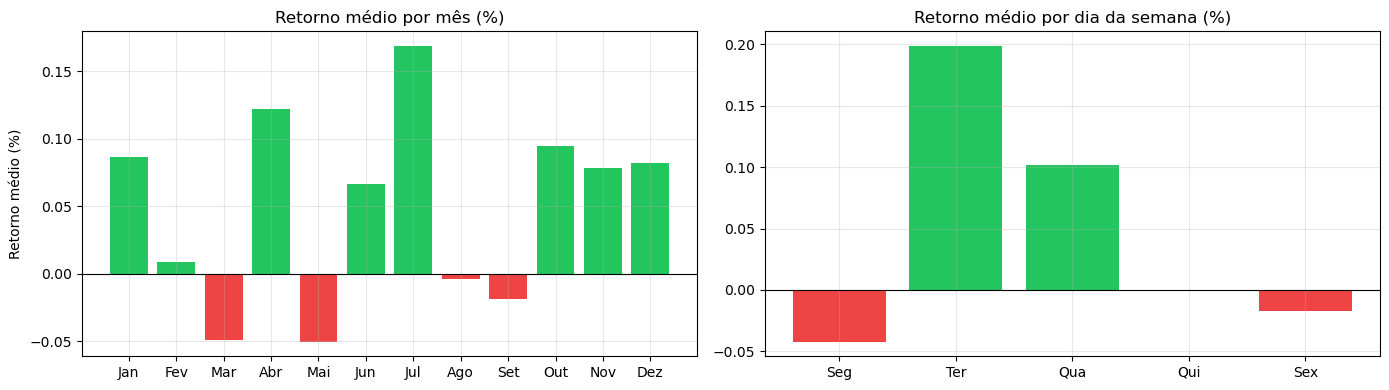

In [15]:
raw['mes']          = raw.index.month
raw['dia_semana']   = raw.index.dayofweek  # 0=seg, 4=sex

ret_mes = raw.groupby('mes')['retorno'].mean()
ret_dia = raw.groupby('dia_semana')['retorno'].mean()

meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
dias  = ['Seg','Ter','Qua','Qui','Sex']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors_mes = ['#22c55e' if v > 0 else '#ef4444' for v in ret_mes]
axes[0].bar(meses, ret_mes * 100, color=colors_mes)
axes[0].set_title('Retorno médio por mês (%)')
axes[0].set_ylabel('Retorno médio (%)')
axes[0].axhline(0, color='black', linewidth=0.8)

colors_dia = ['#22c55e' if v > 0 else '#ef4444' for v in ret_dia]
axes[1].bar(dias, ret_dia * 100, color=colors_dia)
axes[1].set_title('Retorno médio por dia da semana (%)')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 6. Drawdown histórico

In [16]:
preco = raw['close']
rolling_max = preco.cummax()
drawdown = (preco - rolling_max) / rolling_max

print(f'Máximo drawdown histórico: {drawdown.min():.2%}')
print(f'Data do pior drawdown:     {drawdown.idxmin().date()}')

fig = go.Figure()
fig.add_trace(go.Scatter(x=drawdown.index, y=drawdown * 100,
                         fill='tozeroy', fillcolor='rgba(239,68,68,0.15)',
                         line=dict(color='#ef4444', width=1.2),
                         name='Drawdown'))
fig.update_layout(title='Drawdown histórico do BOVA11',
                  yaxis_title='Drawdown (%)',
                  template='plotly_white', height=350)
fig.show()

Máximo drawdown histórico: -46.93%
Data do pior drawdown:     2020-03-23


## 7. Salvar dados processados

In [17]:
import os
os.makedirs('../data/processed', exist_ok=True)

raw.to_parquet('../data/processed/bova11_eda.parquet')
print(f'Dados salvos: {raw.shape[0]} linhas, {raw.shape[1]} colunas')
print('Próximo passo → 02_features.ipynb')

Dados salvos: 2459 linhas, 11 colunas
Próximo passo → 02_features.ipynb


---
## Conclusões da EDA

- Retornos apresentam **curtose elevada** (caudas pesadas), comportamento típico de séries financeiras
- Leve **assimetria negativa** — quedas tendem a ser mais intensas que altas
- Sazonalidade mensalmente observável, porém de uso limitado como feature isolada
- Volatilidade claramente não-estacionária com **clusters** evidentes (COVID-19, eleições 2022)
- Drawdown máximo histórico no período coincide com choques macroeconômicos exógenos

→ **Feature engineering** no próximo notebook irá capturar regime de volatilidade, momentum e tendência de forma quantitativa.